<a href="https://colab.research.google.com/github/ene23033/repository/blob/master/POA_NASA_Sol_PVMMS_hourly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df1 = pd.read_csv('/content/NASA+ground POA.csv')

df1.index = pd.to_datetime(df1['timestamp'], format='%d-%m-%Y %H:%M')
df1['y'] = pd.to_datetime(df1['timestamp'], format='%d-%m-%Y %H:%M').dt.year
df1['h'] = pd.to_datetime(df1['timestamp'], format='%d-%m-%Y %H:%M').dt.hour
df1.head()

,timestamp,DHI,DNI,GHI,T2M,WS10M,Active_Power,Temp1,Temp2,poa,zenith,azimuth,beam,sky,NASA_poa,y,h
timestamp,,,,,,,,,,,,,,,,,
2015-03-01 00:00:00,01-03-2015 00:00,0.0,0.0,0.0,20.78,2.31,-0.000023,20.3,20.1,-1.110,163.300064,310.657868,0.0,0.0,0.0,2015,0
2015-03-01 01:00:00,01-03-2015 01:00,0.0,0.0,0.0,20.66,2.44,-0.000030,20.0,19.8,-0.947,168.511951,11.453697,0.0,0.0,0.0,2015,1
2015-03-01 02:00:00,01-03-2015 02:00,0.0,0.0,0.0,20.27,2.49,-0.000008,20.3,20.2,-0.712,159.779563,58.410139,0.0,0.0,0.0,2015,2
2015-03-01 03:00:00,01-03-2015 03:00,0.0,0.0,0.0,20.08,2.76,-0.000023,20.0,19.9,-0.939,146.705216,74.599767,0.0,0.0,0.0,2015,3
2015-03-01 04:00:00,01-03-2015 04:00,0.0,0.0,0.0,19.94,2.82,-0.000008,19.5,19.7,-1.490,132.797151,82.813901,0.0,0.0,0.0,2015,4


In [5]:
df2 = pd.read_csv('/content/POA_solcast_SCADA.csv')

df2.index = pd.to_datetime(df2['timestamp'], format='%d-%m-%Y %H:%M')
df2['y'] = pd.to_datetime(df2['timestamp'], format='%d-%m-%Y %H:%M').dt.year
df2['h'] = pd.to_datetime(df2['timestamp'], format='%d-%m-%Y %H:%M').dt.hour
df2.head()

,air_temp,azimuth,clearsky_dhi,clearsky_dni,clearsky_ghi,dewpoint_temp,dhi,dni,ghi,precipitation_rate,...,timestamp,Active_Power,Temp1,Temp2,poa,h,beam,sky,Solcast_poa,y
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-03-01 00:00:00,22,29,0,0,0,18.2,0.0,0.0,0.0,0.4,...,01-03-2015 00:00,-0.000023,20.3,20.1,-1.110,0.0,0.0,0.0,0.0,2015.0
2015-03-01 00:05:00,22,24,0,0,0,18.2,0.0,0.0,0.0,0.7,...,01-03-2015 00:05,-0.000024,20.3,20.1,-0.965,0.0,0.0,0.0,0.0,2015.0
2015-03-01 00:10:00,22,18,0,0,0,18.2,0.0,0.0,0.0,0.7,...,01-03-2015 00:10,-0.000028,20.4,20.2,-0.887,0.0,0.0,0.0,0.0,2015.0
2015-03-01 00:15:00,22,12,0,0,0,18.2,0.0,0.0,0.0,0.7,...,01-03-2015 00:15,-0.000025,20.4,20.2,-0.826,0.0,0.0,0.0,0.0,2015.0
2015-03-01 00:20:00,22,5,0,0,0,18.1,0.0,0.0,0.0,0.7,...,01-03-2015 00:20,-0.000018,20.4,20.3,-0.803,0.0,0.0,0.0,0.0,2015.0


In [6]:
df3=pd.merge(df1,df2,left_on=df1.index,right_on=df2.index,how='inner')
df3.to_csv('Merged_hourly_NASA_Sol_PVMMS.csv',index=False)
df3.head()

,key_0,timestamp_x,DHI,DNI,GHI,T2M,WS10M,Active_Power_x,Temp1_x,Temp2_x,...,timestamp_y,Active_Power_y,Temp1_y,Temp2_y,poa_y,h_y,beam_y,sky_y,Solcast_poa,y_y
0,2015-03-01 00:00:00,01-03-2015 00:00,0.0,0.0,0.0,20.78,2.31,-0.000023,20.3,20.1,...,01-03-2015 00:00,-0.000023,20.3,20.1,-1.110,0.0,0.0,0.0,0.0,2015.0
1,2015-03-01 01:00:00,01-03-2015 01:00,0.0,0.0,0.0,20.66,2.44,-0.000030,20.0,19.8,...,01-03-2015 01:00,-0.000030,20.0,19.8,-0.947,1.0,0.0,0.0,0.0,2015.0
2,2015-03-01 02:00:00,01-03-2015 02:00,0.0,0.0,0.0,20.27,2.49,-0.000008,20.3,20.2,...,01-03-2015 02:00,-0.000008,20.3,20.2,-0.712,2.0,0.0,0.0,0.0,2015.0
3,2015-03-01 03:00:00,01-03-2015 03:00,0.0,0.0,0.0,20.08,2.76,-0.000023,20.0,19.9,...,01-03-2015 03:00,-0.000023,20.0,19.9,-0.939,3.0,0.0,0.0,0.0,2015.0
4,2015-03-01 04:00:00,01-03-2015 04:00,0.0,0.0,0.0,19.94,2.82,-0.000008,19.5,19.7,...,01-03-2015 04:00,-0.000008,19.5,19.7,-1.490,4.0,0.0,0.0,0.0,2015.0


In [7]:
df4 = pd.read_csv('/content/Merged_hourly_NASA_Sol_PVMMS.csv')

df4.index = pd.to_datetime(df4['timestamp'], format='%d-%m-%Y %H:%M')
df4['y'] = pd.to_datetime(df4['timestamp'], format='%d-%m-%Y %H:%M').dt.year
df4['h'] = pd.to_datetime(df4['timestamp'], format='%d-%m-%Y %H:%M').dt.hour
df4.head()

,timestamp,Solcast_poa,PVMMS_poa,NASA_poa,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,y,h
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-03-01 00:00:00,01-03-2015 00:00,0.0,-1.110,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,0
2015-03-01 01:00:00,01-03-2015 01:00,0.0,-0.947,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,1
2015-03-01 02:00:00,01-03-2015 02:00,0.0,-0.712,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,2
2015-03-01 03:00:00,01-03-2015 03:00,0.0,-0.939,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,3
2015-03-01 04:00:00,01-03-2015 04:00,0.0,-1.490,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,4


(-50.0, 1200.0)

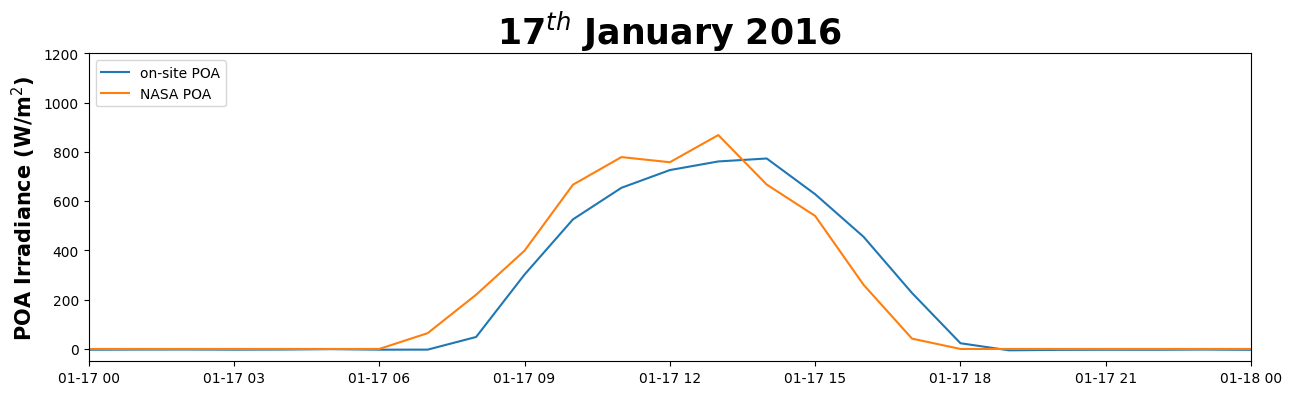

In [8]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df4.index, df4['PVMMS_poa'],  label='on-site POA')
ax.plot(df4.index, df4['NASA_poa'],  label='NASA POA')
ax.set_xlim(pd.Timestamp('2016-01-17'), pd.Timestamp('2016-01-18'))
ax.set_ylabel('POA Irradiance (W/m$^2$)', fontsize=15, weight='bold')
ax.legend(loc='upper left')
ax.set_title('17$^{th}$ January 2016', weight='bold', fontsize=25)
ax.set_ylim(-50, 1200)

(-50.0, 1200.0)

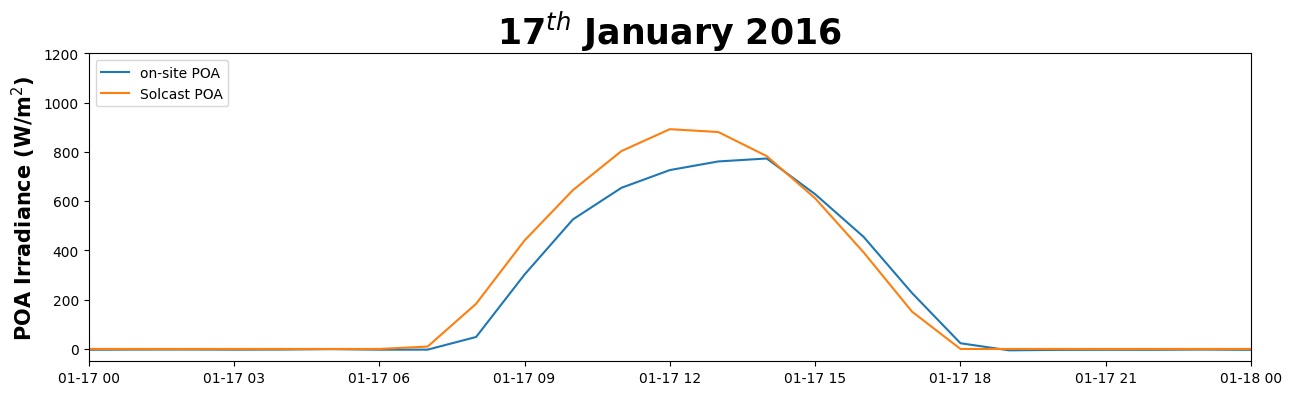

In [25]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df4.index, df4['PVMMS_poa'],  label='on-site POA')
ax.plot(df4.index, df4['Solcast_poa'],  label='Solcast POA')
ax.set_xlim(pd.Timestamp('2016-01-17'), pd.Timestamp('2016-01-18'))
ax.set_ylabel('POA Irradiance (W/m$^2$)', fontsize=15, weight='bold')
ax.legend(loc='upper left')
ax.set_title('17$^{th}$ January 2016', weight='bold', fontsize=25)
ax.set_ylim(-50, 1200)

(-50.0, 1200.0)

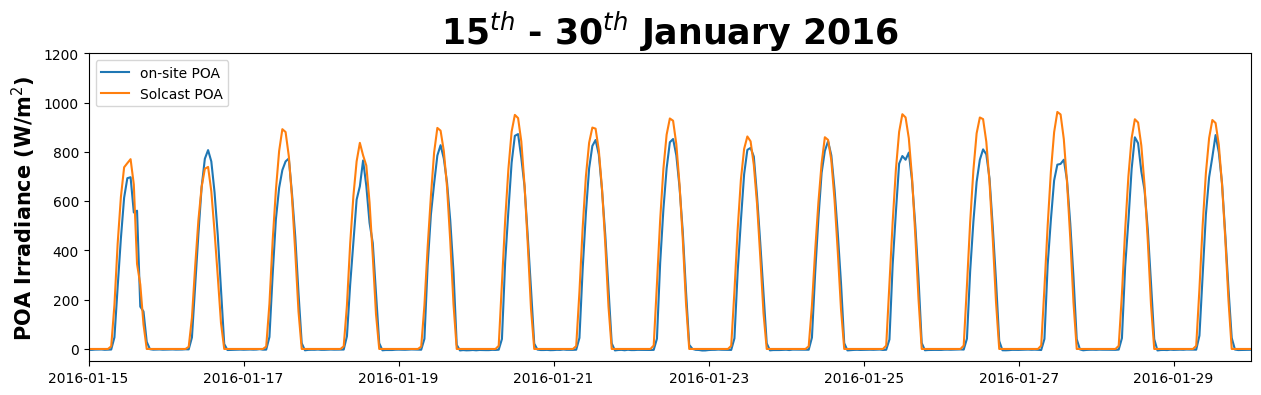

In [10]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df4.index, df4['PVMMS_poa'],  label='on-site POA')
ax.plot(df4.index, df4['Solcast_poa'], label='Solcast POA')
ax.set_xlim(pd.Timestamp('2016-01-15'), pd.Timestamp('2016-01-30'))
ax.set_ylabel('POA Irradiance (W/m$^2$)', fontsize=15, weight='bold')
ax.legend(loc='upper left')
ax.set_title('15$^{th}$ - 30$^{th}$ January 2016', weight='bold', fontsize=25)
ax.set_ylim(-50, 1200)

(-50.0, 1200.0)

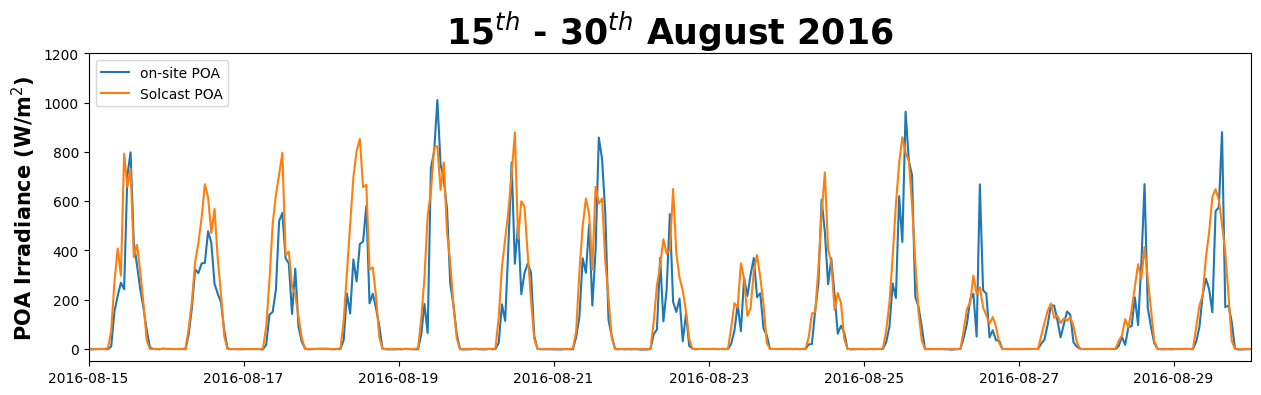

In [11]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df4.index, df4['PVMMS_poa'],  label='on-site POA')
ax.plot(df4.index, df4['Solcast_poa'], label='Solcast POA')
ax.set_xlim(pd.Timestamp('2016-08-15'), pd.Timestamp('2016-08-30'))
ax.set_ylabel('POA Irradiance (W/m$^2$)', fontsize=15, weight='bold')
ax.legend(loc='upper left')
ax.set_title('15$^{th}$ - 30$^{th}$ August 2016', weight='bold', fontsize=25)
ax.set_ylim(-50, 1200)

(-50.0, 1200.0)

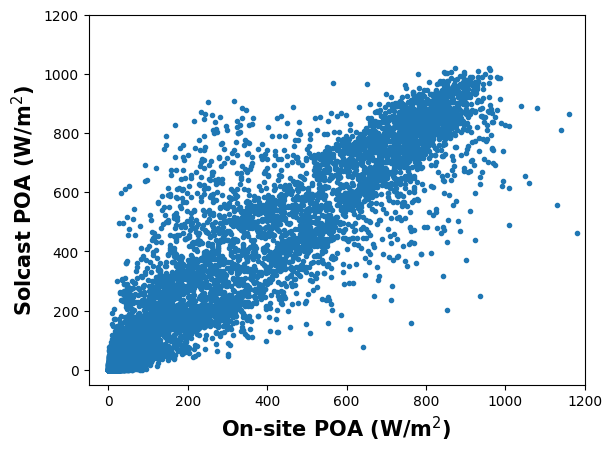

In [15]:
fig,ax = plt.subplots()
ax.plot(df4['PVMMS_poa'][(df4['PVMMS_poa']>0) & (df4['PVMMS_poa']<1200)], df4['Solcast_poa'][(df4['PVMMS_poa']>0) & (df4['PVMMS_poa']<1200)],
        'o', markersize='3')
ax.set_ylabel('Solcast POA (W/m$^2$)', weight='bold', fontsize=15)
ax.set_xlabel('On-site POA (W/m$^2$)', weight='bold', fontsize=15)
plt.ylim(-50, 1200)
plt.xlim(-50, 1200)

In [16]:
df4['PVMMS_poa'][(df4['PVMMS_poa']>0) & (df4['PVMMS_poa']<1200)].corr(df4['Solcast_poa'][(df4['PVMMS_poa']>0) & (df4['PVMMS_poa']<1200)])

0.9146389865568918

In [19]:
df4['m'] = pd.to_datetime(df4['timestamp'], format='%d-%m-%Y %H:%M').dt.month
df4['y'] = pd.to_datetime(df4['timestamp'], format='%d-%m-%Y %H:%M').dt.year
df4['h'] = pd.to_datetime(df4['timestamp'], format='%d-%m-%Y %H:%M').dt.hour

s = pd.DataFrame(df4[df4['y']==2016])

s['period'] = np.nan
s['period'][(s['m']>=1) & (s['m']<=4)] = 'P1'
s['period'][(s['m']>=6) & (s['m']<=9)] = 'P2'
s['period'][s['m']>9] = 'P3'

s.head()

<ipython-input-19-d0672b0c04b0>:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  s['period'][(s['m']>=1) & (s['m']<=4)] = 'P1'
<ipython-input-19-d0672b0c04b0>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

,timestamp,Solcast_poa,PVMMS_poa,NASA_poa,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,y,h,m,period
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,01-01-2016 00:00,0.0,-3.32,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2016,0,1,P1
2016-01-01 01:00:00,01-01-2016 01:00,0.0,-4.24,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2016,1,1,P1
2016-01-01 02:00:00,01-01-2016 02:00,0.0,-3.88,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2016,2,1,P1
2016-01-01 03:00:00,01-01-2016 03:00,0.0,-3.81,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2016,3,1,P1
2016-01-01 04:00:00,01-01-2016 04:00,0.0,-3.59,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2016,4,1,P1


In [23]:
z = pd.DataFrame(df4[df4['y']==2016])

z['period'] = np.nan
z['period'][(z['h']>=8) & (z['h']<10)] = 'T1'
z['period'][(z['h']>=10) & (z['h']<14)] = 'T2'
z['period'][(z['h']>=14) & (z['h']<=17)] = 'T3'

z = z.dropna()
z.head()

<ipython-input-23-a35ee85f8ffa>:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  z['period'][(z['h']>=8) & (z['h']<10)] = 'T1'
<ipython-input-23-a35ee85f8ffa>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

,timestamp,Solcast_poa,PVMMS_poa,NASA_poa,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,y,h,m,period
timestamp,,,,,,,,,,,,,,,,,,,,,


(-50.0, 1200.0)

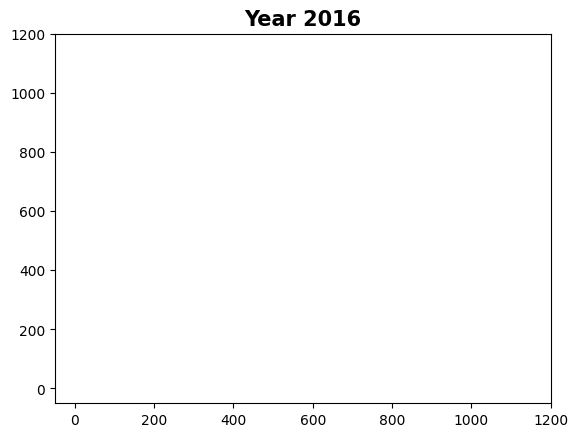

In [24]:
sns.scatterplot(x=z['PVMMS_poa'][(z['PVMMS_poa']>0) & (z['PVMMS_poa']<1200)],
                y=z['Solcast_poa'][(z['PVMMS_poa']>0) & (z['PVMMS_poa']<1200)],
                hue=z['period'][(z['PVMMS_poa']>0) & (z['PVMMS_poa']<1200)], data=s)
plt.title('Year 2016', weight='bold', fontsize=15)
plt.ylim(-50, 1200)
plt.xlim(-50, 1200)

(-50.0, 1200.0)

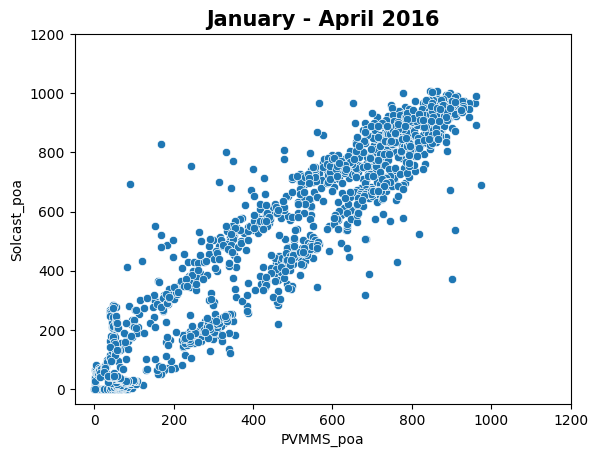

In [22]:

sns.scatterplot(x=s['PVMMS_poa'][(s['PVMMS_poa']>0) & (s['PVMMS_poa']<1200) & (s['period']=='P1')],
                y=s['Solcast_poa'][(s['PVMMS_poa']>0) & (s['PVMMS_poa']<1200) & (s['period']=='P1')], data=s)
plt.title('January - April 2016', weight='bold', fontsize=15)
plt.ylim(-50, 1200)
plt.xlim(-50, 1200)